In [18]:
import tensorflow as tf
import numpy as np
import matplotlib as mpl
import IPython.display as display
import PIL.Image
import cv2

In [19]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


In [20]:
# Download an image and read it into a NumPy array.
def download(url, max_dim=None):
    name = url.split('/')[-1]
    image_path = tf.keras.utils.get_file(name, origin=url)
    img = PIL.Image.open(image_path)
    if max_dim:
        img.thumbnail((max_dim, max_dim))
    return np.array(img)

In [21]:
# Normalize an image
def deprocess(img):
    img = 255*(img + 1.0)/2.0
    return tf.cast(img, tf.uint8)

In [22]:
# Display an image
def show(img):
    display.display(PIL.Image.fromarray(np.array(img)))

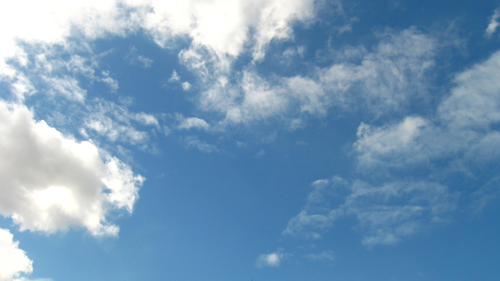

In [23]:
# Download a new image
url = 'https://upload.wikimedia.org/wikipedia/commons/1/16/Appearance_of_sky_for_weather_forecast%2C_Dhaka%2C_Bangladesh.JPG'
original_img = download(url, max_dim=500)

# Resize the input image to (150, 150)
resized_img = cv2.resize(original_img, (150, 150))

show(original_img)

In [24]:
# Prepare the feature extraction model
#base_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
base_model = tf.keras.applications.InceptionV3(include_top=False, weights='inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5', input_shape=(150, 150, 3))

In [25]:
# Maximize the activations of these layers
layer_names = ['mixed3', 'mixed5', 'mixed7']  # Adjusted layers for experimentation
layers = [base_model.get_layer(name).output for name in layer_names]

In [26]:
# Create the feature extraction model
dream_model = tf.keras.Model(inputs=base_model.input, outputs=layers)

In [27]:
# Calculate loss
def calc_loss(img, model):
    img_batch = tf.expand_dims(img, axis=0)
    layer_activations = model(img_batch)
    if len(layer_activations) == 1:
        layer_activations = [layer_activations]

    losses = []
    for act in layer_activations:
        loss = tf.math.reduce_mean(act)
        losses.append(loss)

    return  tf.reduce_sum(losses)

In [28]:
# Gradient ascent
class DeepDream(tf.Module):
    def __init__(self, model):
        self.model = model

    @tf.function
    def __call__(self, img, steps, step_size):
        loss = tf.constant(0.0)
        for _ in tf.range(steps):
            with tf.GradientTape() as tape:
                tape.watch(img)
                loss = calc_loss(img, self.model)

            gradients = tape.gradient(loss, img)
            gradients /= tf.math.reduce_std(gradients) + 1e-8 
            img = img + gradients*step_size
            img = tf.clip_by_value(img, -1, 1)

        return loss, img 

In [29]:
deepdream = DeepDream(dream_model) 

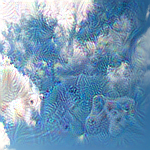

In [31]:
# Main Loop
def run_deep_dream_simple(img, steps=100, step_size=0.01):
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    img = tf.convert_to_tensor(img)
    step_size = tf.convert_to_tensor(step_size)
    steps_remaining = steps
    step = 0
    while steps_remaining:
        if steps_remaining > 100:
            run_steps = tf.constant(100)
        else:
            run_steps = tf.constant(steps_remaining)
        steps_remaining -= run_steps
        step += run_steps

        loss, img = deepdream(img, run_steps, tf.constant(step_size))
        display.clear_output(wait=True)
        show(deprocess(img))
        print("Step {}, loss {}".format(step, loss))

    result = deprocess(img)
    display.clear_output(wait=True)
    show(result)

    return result

dream_img = run_deep_dream_simple(img=resized_img, steps=100, step_size=0.01)